# Notebook 05 — Feature Engineering, Clustering & Recommendation

Notebook này dùng **586,672 track thật** từ `ml_ready_dataset.parquet`. Mục tiêu chính là popularity regression; KMeans và content-based recommendation là hai nhiệm vụ phụ độc lập.

Luồng chống leakage: **fit trên train (`release_year < 2019`) → đóng băng statistics → transform train/test/inference**. Target không bao giờ được truyền vào `FeatureBuilder`, KMeans hay recommender.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    for candidate in Path.cwd().resolve().parents:
        if (candidate / "src").exists() and (candidate / "5.DATA").exists():
            ROOT = candidate
            break
sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

import matplotlib.pyplot as plt

from src.features import (
    BASELINE_MODEL_FEATURES, CANDIDATE_ENGINEERED_FEATURES,
    CANDIDATE_ENGINEERED_CATEGORICAL_FEATURES, CLUSTER_FEATURES,
    IDENTIFIER, MODEL_FEATURES, RAW_INPUT_FEATURES,
    RECOMMENDATION_FEATURES, SELECTED_ENGINEERED_FEATURES,
    TARGET, TEST_START_YEAR, FeatureBuilder, build_feature_contract,
    validate_selected_engineered_features,
)
from src.secondary_tasks import (
    cluster_profiles, fit_cluster_pipeline, fit_recommender,
    recommend_by_track_id, select_kmeans_k,
)

DATA_PATH = ROOT / "5.DATA" / "processed" / "ml_ready_dataset.parquet"
OUTPUT_DIR = ROOT / "5.DATA" / "processed"
FE_DIR = ROOT / "7.ML" / "7.6.feature_engineering"
SECONDARY_DIR = ROOT / "4.MODELS" / "hitradar_secondary"
for directory in (OUTPUT_DIR, FE_DIR, SECONDARY_DIR):
    directory.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), "Real dataset is required; no synthetic fallback is allowed."

Project root: D:\Hitradar\hitradar-main


## 1. Dữ liệu thật và time split

`target_popularity` là tên nội bộ của Spotify popularity (0–100). `track_id` chỉ là định danh, không phải model feature.

In [2]:
df_raw = pd.read_parquet(DATA_PATH)
required = [IDENTIFIER, TARGET, *RAW_INPUT_FEATURES]
missing_source = [c for c in required if c not in df_raw.columns]
assert not missing_source, f"Missing source columns: {missing_source}"
train_mask = pd.to_numeric(df_raw["release_year"], errors="coerce") < TEST_START_YEAR
assert train_mask.any() and (~train_mask).any()
print("Shape before Feature Engineering:", df_raw.shape)
print(f"Train rows: {train_mask.sum():,}; test rows: {(~train_mask).sum():,}")
display(df_raw[[IDENTIFIER, TARGET, *RAW_INPUT_FEATURES[:6]]].head())

Shape before Feature Engineering: (586672, 20)
Train rows: 554,547; test rows: 32,125


,track_id,target_popularity,duration_min,explicit,release_year,release_month,release_precision,danceability
0,0HOqINudNgQFpg1le5Hnqe,62,5.1767,True,1992,11.0,day,0.785
1,2Mb3zpobD0CvJGWv6NpsPy,62,4.7782,False,1992,5.0,day,0.761
2,2WElktskrNJEwgpp5Vouxk,62,2.8411,False,1992,1.0,day,0.683
3,6FHXJu99aQAUnivEjPhuUR,62,3.5333,False,1992,1.0,day,0.526
4,1QbQL5m30YNvukitIqAnFG,62,5.3421,False,1992,1.0,day,0.686


## 2. Candidate register có căn cứ EDA

Notebook 04 cho thấy audio variables có phân phối lệch, quan hệ popularity không hoàn toàn tuyến tính, và có thay đổi mạnh theo thời gian. Vì vậy candidate register kiểm tra interaction, cyclic key, category và độ lệch so với trung bình lịch sử. Mood dùng mốc 0.5 vì energy/valence đã chuẩn hóa [0,1]; duration và tempo dùng quantile **học từ train** để tránh ngưỡng tùy ý và tránh test leakage.

In [3]:
FORMULAS = {
 "key_sin":"sin(2*pi*(key mod 12)/12)", "key_cos":"cos(2*pi*(key mod 12)/12)",
 "dance_energy":"danceability * energy", "positive_energy":"valence * energy",
 "acoustic_energy_balance":"acousticness / (acousticness + energy + epsilon)",
 "dance_valence":"danceability * valence",
 "acoustic_instrumental":"acousticness * instrumentalness",
 "tempo_energy":"tempo * energy", "energy_loudness":"energy * loudness",
 "speechiness_log":"log1p(max(speechiness, 0))",
 "instrumentalness_log":"log1p(max(instrumentalness, 0))",
 "mood_quadrant":"energy/valence quadrants at normalized midpoint 0.5",
 "duration_category":"short/standard/long from train q33/q67",
 "tempo_category":"four bins from train q25/q50/q75",
 "energy_vs_period_avg":"energy - train decade energy mean",
 "dance_vs_period_avg":"danceability - train decade danceability mean",
}
EDA_EVIDENCE = {
 "key_sin":"NB04 correlation review: key is cyclic, so endpoints 0/11 must be adjacent.",
 "key_cos":"NB04 correlation review: complementary coordinate required for cyclic key.",
 "dance_energy":"NB04 audio distributions/correlation: danceability and energy may act jointly.",
 "positive_energy":"NB04 nonlinear bins: valence and energy jointly describe intensity/mood.",
 "acoustic_energy_balance":"NB04 audio distributions: acousticness and energy oppose each other strongly.",
 "dance_valence":"NB04 nonlinear bins: danceability and valence show non-additive patterns.",
 "acoustic_instrumental":"NB04 right-skew review: acoustic/instrumental content co-occurs.",
 "tempo_energy":"NB04 audio review: speed and energy jointly express intensity.",
 "energy_loudness":"NB04 correlation review: loudness and energy are related but not identical.",
 "speechiness_log":"NB04 distribution review: speechiness is right-skewed.",
 "instrumentalness_log":"NB04 distribution review: instrumentalness is right-skewed.",
 "mood_quadrant":"NB04 normalized audio review supports interpretable mood quadrants.",
 "duration_category":"NB04 duration/time trends show nonlinear duration behavior.",
 "tempo_category":"NB04 nonlinear binned plots motivate tempo regimes.",
 "energy_vs_period_avg":"NB04 decade trends show energy changes over time.",
 "dance_vs_period_avg":"NB04 decade trends show danceability changes over time.",
}
candidate_register = pd.DataFrame({
    "Feature": CANDIDATE_ENGINEERED_FEATURES,
    "Formula": [FORMULAS[f] for f in CANDIDATE_ENGINEERED_FEATURES],
    "Type": ["categorical" if f in CANDIDATE_ENGINEERED_CATEGORICAL_FEATURES else "numeric" for f in CANDIDATE_ENGINEERED_FEATURES],
    "Expected Benefit": [EDA_EVIDENCE[f] for f in CANDIDATE_ENGINEERED_FEATURES],
    "EDA Source": ["Notebook 04 — EDA" for _ in CANDIDATE_ENGINEERED_FEATURES],
})
display(candidate_register)

,Feature,Formula,Type,Expected Benefit,EDA Source
0,key_sin,sin(2*pi*(key mod 12)/12),numeric,"NB04 correlation review: key is cyclic, so end...",Notebook 04 — EDA
1,key_cos,cos(2*pi*(key mod 12)/12),numeric,NB04 correlation review: complementary coordin...,Notebook 04 — EDA
2,dance_energy,danceability * energy,numeric,NB04 audio distributions/correlation: danceabi...,Notebook 04 — EDA
3,positive_energy,valence * energy,numeric,NB04 nonlinear bins: valence and energy jointl...,Notebook 04 — EDA
4,acoustic_energy_balance,acousticness / (acousticness + energy + epsilon),numeric,NB04 audio distributions: acousticness and ene...,Notebook 04 — EDA
5,dance_valence,danceability * valence,numeric,NB04 nonlinear bins: danceability and valence ...,Notebook 04 — EDA
6,acoustic_instrumental,acousticness * instrumentalness,numeric,NB04 right-skew review: acoustic/instrumental ...,Notebook 04 — EDA
7,tempo_energy,tempo * energy,numeric,NB04 audio review: speed and energy jointly ex...,Notebook 04 — EDA
8,energy_vs_period_avg,energy - train decade energy mean,numeric,NB04 decade trends show energy changes over time.,Notebook 04 — EDA
9,dance_vs_period_avg,danceability - train decade danceability mean,numeric,NB04 decade trends show danceability changes o...,Notebook 04 — EDA


## 3. Tạo thật toàn bộ candidate bằng shared `FeatureBuilder`

Code bên dưới tạo columns thật. Learned thresholds và period means chỉ fit bằng train rows.

In [4]:
feature_builder = FeatureBuilder(include_engineered=True).fit(
    df_raw.loc[train_mask, RAW_INPUT_FEATURES]
)
candidate_matrix = feature_builder.transform_candidates(df_raw[RAW_INPUT_FEATURES])
selected_matrix = feature_builder.transform(df_raw[RAW_INPUT_FEATURES])
df = pd.concat(
    [df_raw[[IDENTIFIER, TARGET]].reset_index(drop=True), selected_matrix.reset_index(drop=True)],
    axis=1,
)
print("Shape after selected Feature Engineering:", df.shape)
print("Implemented candidates:", len(CANDIDATE_ENGINEERED_FEATURES))
print("Selected engineered features:", len(SELECTED_ENGINEERED_FEATURES))
display(pd.concat([df_raw[[IDENTIFIER, TARGET]].head(5).reset_index(drop=True),
                   candidate_matrix[CANDIDATE_ENGINEERED_FEATURES].head(5).reset_index(drop=True)], axis=1))

Shape after selected Feature Engineering: (586672, 34)
Implemented candidates: 16
Selected engineered features: 14


,track_id,target_popularity,key_sin,key_cos,dance_energy,positive_energy,acoustic_energy_balance,dance_valence,acoustic_instrumental,tempo_energy,energy_vs_period_avg,dance_vs_period_avg,energy_loudness,speechiness_log,instrumentalness_log,mood_quadrant,duration_category,tempo_category
0,0HOqINudNgQFpg1le5Hnqe,62,0.500000,8.660254e-01,0.622505,0.519415,0.217176,0.514175,1.579600e-01,70.499286,0.218618,0.212911,-6.276595,0.151003,0.541161,high_energy_positive,long,slow
1,2Mb3zpobD0CvJGWv6NpsPy,62,0.866025,5.000000e-01,0.519763,0.458293,0.171116,0.510631,0.000000e+00,69.520521,0.108618,0.188911,-7.437187,0.151862,0.000000,high_energy_positive,long,moderate
2,2WElktskrNJEwgpp5Vouxk,62,-0.500000,8.660254e-01,0.504737,0.617804,0.000066,0.570988,5.990200e-07,90.241507,0.164618,0.110911,-9.482109,0.048314,0.012126,high_energy_positive,short,fast
3,6FHXJu99aQAUnivEjPhuUR,62,1.000000,6.123234e-17,0.232492,0.125528,0.376586,0.149384,1.465830e-05,57.926310,-0.132382,-0.046089,-4.478786,0.025570,0.000055,calm_dark,standard,fast
4,1QbQL5m30YNvukitIqAnFG,62,-0.866025,5.000000e-01,0.417774,0.437871,0.297578,0.493234,3.870000e-05,77.791224,0.034618,0.113911,-6.984621,0.043443,0.000150,high_energy_positive,long,fast


## 4. Candidate evaluation và quyết định Keep/Drop

Association là |Spearman| cho numeric và correlation ratio (η) cho categorical. Redundancy numeric là |Spearman| lớn nhất với raw numeric features. Tính trên deterministic train sample để audit có thể chạy lại; target chỉ dùng để **đánh giá candidate sau khi tạo**, tuyệt đối không tham gia công thức/fit.

In [5]:
audit_index = df_raw.loc[train_mask].sample(
    min(120_000, int(train_mask.sum())), random_state=1512
).index
audit_X = candidate_matrix.loc[audit_index]
audit_y = pd.to_numeric(df_raw.loc[audit_index, TARGET], errors="coerce")
raw_numeric = [c for c in BASELINE_MODEL_FEATURES if c in audit_X and pd.api.types.is_numeric_dtype(audit_X[c])]

def association(series, target):
    if pd.api.types.is_numeric_dtype(series):
        return abs(float(pd.to_numeric(series, errors="coerce").corr(target, method="spearman")))
    temp = pd.DataFrame({"x": series.astype("string"), "y": target}).dropna()
    grand = temp["y"].mean()
    between = sum(len(g) * (g["y"].mean() - grand) ** 2 for _, g in temp.groupby("x", observed=True))
    total = ((temp["y"] - grand) ** 2).sum()
    return float(np.sqrt(between / total)) if total else 0.0

def redundancy(feature):
    s = audit_X[feature]
    if not pd.api.types.is_numeric_dtype(s):
        return np.nan
    return max(abs(float(pd.to_numeric(s, errors="coerce").corr(
        pd.to_numeric(audit_X[c], errors="coerce"), method="spearman"))) for c in raw_numeric)

candidate_evaluation = candidate_register.copy()
candidate_evaluation["Missing Count"] = [int(candidate_matrix[f].isna().sum()) for f in CANDIDATE_ENGINEERED_FEATURES]
candidate_evaluation["Infinite Count"] = [int(np.isinf(candidate_matrix[f].to_numpy(dtype=float)).sum()) if pd.api.types.is_numeric_dtype(candidate_matrix[f]) else 0 for f in CANDIDATE_ENGINEERED_FEATURES]
candidate_evaluation["Target Association"] = [association(audit_X[f], audit_y) for f in CANDIDATE_ENGINEERED_FEATURES]
candidate_evaluation["Max Raw Redundancy"] = [redundancy(f) for f in CANDIDATE_ENGINEERED_FEATURES]
candidate_evaluation["Leakage Check"] = "PASS — formula/fit excludes target"
candidate_evaluation["Interpretability"] = "PASS"
candidate_evaluation["Decision"] = candidate_evaluation["Feature"].map(lambda f: "KEEP" if f in SELECTED_ENGINEERED_FEATURES else "DROP")
candidate_evaluation["Decision Reason"] = candidate_evaluation["Feature"].map({
    "speechiness_log":"DROP: exact monotonic rank redundancy with retained raw speechiness.",
    "instrumentalness_log":"DROP: exact monotonic rank redundancy with retained raw instrumentalness.",
}).fillna("KEEP: executable, valid, leakage-safe candidate with EDA/domain rationale.")
assert set(candidate_evaluation.query("Decision == 'KEEP'")["Feature"]) == set(SELECTED_ENGINEERED_FEATURES)
display(candidate_evaluation.sort_values(["Decision", "Target Association"], ascending=[True, False]))

,Feature,Formula,Type,Expected Benefit,EDA Source,Missing Count,Infinite Count,Target Association,Max Raw Redundancy,Leakage Check,Interpretability,Decision,Decision Reason
12,instrumentalness_log,"log1p(max(instrumentalness, 0))",numeric,NB04 distribution review: instrumentalness is ...,Notebook 04 — EDA,0,0,0.222981,1.000000,PASS — formula/fit excludes target,PASS,DROP,DROP: exact monotonic rank redundancy with ret...
11,speechiness_log,"log1p(max(speechiness, 0))",numeric,NB04 distribution review: speechiness is right...,Notebook 04 — EDA,0,0,0.048944,1.000000,PASS — formula/fit excludes target,PASS,DROP,DROP: exact monotonic rank redundancy with ret...
4,acoustic_energy_balance,acousticness / (acousticness + energy + epsilon),numeric,NB04 audio distributions: acousticness and ene...,Notebook 04 — EDA,0,0,0.369767,0.960292,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
2,dance_energy,danceability * energy,numeric,NB04 audio distributions/correlation: danceabi...,Notebook 04 — EDA,0,0,0.333297,0.867569,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
13,mood_quadrant,energy/valence quadrants at normalized midpoin...,categorical,NB04 normalized audio review supports interpre...,Notebook 04 — EDA,0,0,0.301638,NaN,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
7,tempo_energy,tempo * energy,numeric,NB04 audio review: speed and energy jointly ex...,Notebook 04 — EDA,0,0,0.296426,0.916518,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
6,acoustic_instrumental,acousticness * instrumentalness,numeric,NB04 right-skew review: acoustic/instrumental ...,Notebook 04 — EDA,0,0,0.257428,0.966065,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
14,duration_category,short/standard/long from train q33/q67,categorical,NB04 duration/time trends show nonlinear durat...,Notebook 04 — EDA,0,0,0.214436,NaN,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
3,positive_energy,valence * energy,numeric,NB04 nonlinear bins: valence and energy jointl...,Notebook 04 — EDA,0,0,0.206483,0.825056,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."
15,tempo_category,four bins from train q25/q50/q75,categorical,NB04 nonlinear binned plots motivate tempo reg...,Notebook 04 — EDA,0,0,0.071811,NaN,PASS — formula/fit excludes target,PASS,KEEP,"KEEP: executable, valid, leakage-safe candidat..."


`key_sin` và `key_cos` được giữ như một cặp tọa độ: association riêng lẻ thấp không phủ định giá trị biểu diễn chu kỳ. Các interaction tương quan cao với raw sources vẫn được giữ để mô hình tuyến tính thấy quan hệ nhân; hai log bị drop vì biến đổi đơn điệu cho rank redundancy đúng 1.0 và raw source vẫn có mặt.

In [6]:
statistics = feature_builder.get_learned_statistics()
threshold_table = pd.DataFrame([
    {"Feature":"mood_quadrant", "Thresholds":"energy=0.5, valence=0.5", "Source":"fixed midpoint of normalized [0,1] domain", "Fit Scope":"domain constant"},
    {"Feature":"duration_category", "Thresholds":f"q33={statistics['duration_q33']:.4f}, q67={statistics['duration_q67']:.4f}", "Source":"empirical quantiles", "Fit Scope":"train only"},
    {"Feature":"tempo_category", "Thresholds":f"q25={statistics['tempo_q25']:.3f}, q50={statistics['tempo_q50']:.3f}, q75={statistics['tempo_q75']:.3f}", "Source":"empirical quantiles", "Fit Scope":"train only"},
])
display(threshold_table)

,Feature,Thresholds,Source,Fit Scope
0,mood_quadrant,"energy=0.5, valence=0.5","fixed midpoint of normalized [0,1] domain",domain constant
1,duration_category,"q33=3.1600, q67=4.1112",empirical quantiles,train only
2,tempo_category,"q25=95.441, q50=117.042, q75=136.072",empirical quantiles,train only


## 5. Validation cứng của 14 selected features

Category features tồn tại thật ở dataframe và sẽ được `OneHotEncoder(handle_unknown='ignore')` trong Notebook 06/deployment.

In [7]:
EXPECTED_ENGINEERED_FEATURES = list(SELECTED_ENGINEERED_FEATURES)
missing_features = [f for f in EXPECTED_ENGINEERED_FEATURES if f not in df.columns]
assert len(missing_features) == 0, f"Missing engineered features: {missing_features}"
assert len(EXPECTED_ENGINEERED_FEATURES) >= 12
feature_validation = validate_selected_engineered_features(df)
assert feature_validation["Status"].eq("PASS").all(), feature_validation
assert MODEL_FEATURES == [c for c in MODEL_FEATURES if c in df.columns]
display(feature_validation)

,Feature,Exists,Dtype,Missing Count,Infinite Count,Leakage Check,Decision,Status
0,key_sin,True,float64,0,0,PASS,KEEP,PASS
1,key_cos,True,float64,0,0,PASS,KEEP,PASS
2,dance_energy,True,float64,0,0,PASS,KEEP,PASS
3,positive_energy,True,float64,0,0,PASS,KEEP,PASS
4,acoustic_energy_balance,True,float64,0,0,PASS,KEEP,PASS
5,dance_valence,True,float64,0,0,PASS,KEEP,PASS
6,acoustic_instrumental,True,float64,0,0,PASS,KEEP,PASS
7,tempo_energy,True,float64,0,0,PASS,KEEP,PASS
8,energy_vs_period_avg,True,float64,0,0,PASS,KEEP,PASS
9,dance_vs_period_avg,True,float64,0,0,PASS,KEEP,PASS


## 6. Central feature contract và save/reload

In [8]:
contract = build_feature_contract()
paths = {
    "engineered": OUTPUT_DIR / "features_engineered.parquet",
    "candidate_register": FE_DIR / "candidate_feature_register.csv",
    "candidate_evaluation": FE_DIR / "candidate_feature_evaluation.csv",
    "keep_drop": FE_DIR / "feature_keep_drop_decisions.csv",
    "validation": FE_DIR / "hard_requirement_feature_validation.csv",
    "contract": FE_DIR / "hard_requirement_feature_contract.json",
    "statistics": FE_DIR / "hard_requirement_train_statistics.json",
}
df.to_parquet(paths["engineered"], index=False)
candidate_register.to_csv(paths["candidate_register"], index=False)
candidate_evaluation.to_csv(paths["candidate_evaluation"], index=False)
candidate_evaluation[["Feature", "Decision", "Decision Reason"]].to_csv(paths["keep_drop"], index=False)
feature_validation.to_csv(paths["validation"], index=False)
paths["contract"].write_text(json.dumps(contract, indent=2, ensure_ascii=False), encoding="utf-8")
paths["statistics"].write_text(json.dumps(statistics, indent=2, ensure_ascii=False), encoding="utf-8")
reloaded = pd.read_parquet(paths["engineered"])
assert validate_selected_engineered_features(reloaded)["Status"].eq("PASS").all()
print(json.dumps({k: str(v) for k, v in paths.items()}, indent=2))

{
  "engineered": "D:\\Hitradar\\hitradar-main\\5.DATA\\processed\\features_engineered.parquet",
  "candidate_register": "D:\\Hitradar\\hitradar-main\\7.ML\\7.6.feature_engineering\\candidate_feature_register.csv",
  "candidate_evaluation": "D:\\Hitradar\\hitradar-main\\7.ML\\7.6.feature_engineering\\candidate_feature_evaluation.csv",
  "keep_drop": "D:\\Hitradar\\hitradar-main\\7.ML\\7.6.feature_engineering\\feature_keep_drop_decisions.csv",
  "validation": "D:\\Hitradar\\hitradar-main\\7.ML\\7.6.feature_engineering\\hard_requirement_feature_validation.csv",
  "contract": "D:\\Hitradar\\hitradar-main\\7.ML\\7.6.feature_engineering\\hard_requirement_feature_contract.json",
  "statistics": "D:\\Hitradar\\hitradar-main\\7.ML\\7.6.feature_engineering\\hard_requirement_train_statistics.json"
}


## 7. KMeans: chọn k=2..10 bằng inertia và silhouette

Fit/evaluation dùng đúng `CLUSTER_FEATURES`: audio content, không popularity, không track ID, không release time. k được chọn bằng silhouette cao nhất trên deterministic sample; model cuối fit toàn bộ rows.

,k,Inertia,Silhouette
0,2,240669.871722,0.222715
1,3,211668.992242,0.242156
2,4,191574.228676,0.208835
3,5,175192.442380,0.178855
4,6,163232.556378,0.180629
5,7,152961.096931,0.183596
6,8,144614.730748,0.159708
7,9,136844.786412,0.165486
8,10,130005.860018,0.162542


Chosen k=3: maximum sampled silhouette=0.2422


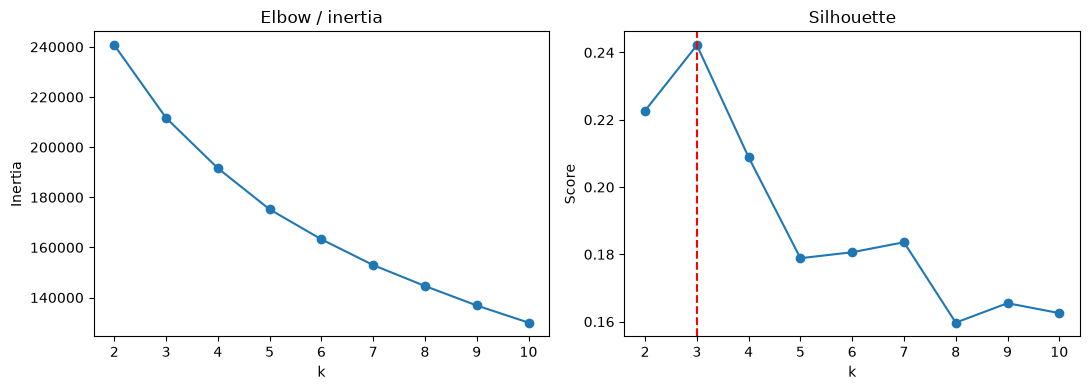

In [9]:
assert TARGET not in CLUSTER_FEATURES and IDENTIFIER not in CLUSTER_FEATURES
assert not {"release_year", "release_month", "decade"}.intersection(CLUSTER_FEATURES)
k_scores, chosen_k = select_kmeans_k(df_raw)
display(k_scores)
print(f"Chosen k={chosen_k}: maximum sampled silhouette={k_scores['Silhouette'].max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_scores["k"], k_scores["Inertia"], marker="o"); axes[0].set(title="Elbow / inertia", xlabel="k", ylabel="Inertia")
axes[1].plot(k_scores["k"], k_scores["Silhouette"], marker="o"); axes[1].axvline(chosen_k, color="red", ls="--"); axes[1].set(title="Silhouette", xlabel="k", ylabel="Score")
plt.tight_layout()
K_PLOT = SECONDARY_DIR / "kmeans_k_selection.png"
fig.savefig(K_PLOT, dpi=140, bbox_inches="tight")
plt.show()

In [10]:
cluster_pipeline = fit_cluster_pipeline(df_raw, chosen_k)
cluster_labels = cluster_pipeline.predict(df_raw[CLUSTER_FEATURES])
profile, profile_by_decade = cluster_profiles(df_raw, cluster_labels)
assignments = pd.DataFrame({IDENTIFIER: df_raw[IDENTIFIER].astype(str), "cluster": cluster_labels})
display(profile)
display(profile_by_decade.tail(20))

KMEANS_PATH = SECONDARY_DIR / "kmeans_pipeline.joblib"
joblib.dump(cluster_pipeline, KMEANS_PATH, compress=3)
k_scores.to_csv(SECONDARY_DIR / "kmeans_k_selection.csv", index=False)
profile.to_csv(SECONDARY_DIR / "cluster_profiles.csv", index=False)
profile_by_decade.to_csv(SECONDARY_DIR / "cluster_profiles_by_decade.csv", index=False)
assignments.to_parquet(SECONDARY_DIR / "cluster_assignments.parquet", index=False)
(SECONDARY_DIR / "cluster_metadata.json").write_text(json.dumps({
    "chosen_k": chosen_k, "selection_rule":"maximum sampled silhouette",
    "features": CLUSTER_FEATURES, "target_used": False, "time_used": False,
    "rows": len(df_raw),
}, indent=2), encoding="utf-8")
print(f"Saved cluster model: {KMEANS_PATH}")

,cluster,duration_min,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Rows
0,0,3.875766,0.612196,0.693639,-7.637433,0.077436,0.254738,0.060386,0.212495,0.639358,124.263928,360568
1,1,3.928778,0.461854,0.286288,-14.167737,0.053982,0.778185,0.224044,0.192952,0.392704,110.304012,199023
2,2,2.585407,0.664184,0.403069,-15.290952,0.843979,0.634936,0.007213,0.387311,0.565907,102.566537,27081


,decade,cluster,Rows,Share Within Decade
14,1960,1,28279,0.598244
15,1960,2,1413,0.029892
16,1970,0,33191,0.536715
17,1970,1,25138,0.406494
18,1970,2,3512,0.056791
19,1980,0,50316,0.611210
20,1980,1,23732,0.288283
21,1980,2,8274,0.100508
22,1990,0,74162,0.681166
23,1990,1,29343,0.269511


Saved cluster model: D:\Hitradar\hitradar-main\4.MODELS\hitradar_secondary\kmeans_pipeline.joblib


## 8. Content-based recommender

Similarity dùng standardized audio + cyclic key, không target/popularity và không thời gian. Dataset local không có track/artist name, nên output trung thực dùng `track_id`; không bịa metadata.

In [11]:
assert TARGET not in RECOMMENDATION_FEATURES and IDENTIFIER not in RECOMMENDATION_FEATURES
assert not {"release_year", "release_month", "decade"}.intersection(RECOMMENDATION_FEATURES)
recommender = fit_recommender(
    df_raw[RAW_INPUT_FEATURES], df_raw[IDENTIFIER], feature_builder=feature_builder
)
RECOMMENDER_PATH = SECONDARY_DIR / "content_recommender.joblib"
joblib.dump(recommender, RECOMMENDER_PATH, compress=3)

example_positions = [0, len(df_raw) // 2, len(df_raw) - 1]
example_frames = []
for position in example_positions:
    query_id = str(df_raw.iloc[position][IDENTIFIER])
    recs = recommend_by_track_id(recommender, query_id, n_recommendations=5)
    assert query_id not in set(recs[IDENTIFIER])
    recs.insert(0, "query_track_id", query_id)
    example_frames.append(recs)
recommendation_examples = pd.concat(example_frames, ignore_index=True)
recommendation_examples.to_csv(SECONDARY_DIR / "recommendation_examples.csv", index=False)
(SECONDARY_DIR / "recommendation_metadata.json").write_text(json.dumps({
    "features": RECOMMENDATION_FEATURES, "metric":"cosine",
    "target_used":False, "time_used":False, "self_excluded":True,
    "metadata_limitation":"Local ML-ready source contains track_id but no track/artist names.",
    "rows":len(df_raw),
}, indent=2), encoding="utf-8")
display(recommendation_examples)
print(f"Saved recommender: {RECOMMENDER_PATH}")

,query_track_id,track_id,cosine_similarity
0,0HOqINudNgQFpg1le5Hnqe,2YSuy9tg3xtb2sKhvMRT3b,0.950803
1,0HOqINudNgQFpg1le5Hnqe,5Nn2Dj7OQsGL6pgQ9iIzPp,0.947264
2,0HOqINudNgQFpg1le5Hnqe,06DXs2hBRdjNs1qE1iYCQQ,0.946462
3,0HOqINudNgQFpg1le5Hnqe,7vGxMdSqL9dSZsoSnOnLL6,0.940326
4,0HOqINudNgQFpg1le5Hnqe,6BWRvw630R8z2vNMok6quI,0.934900
5,4weJob13t4E6IjsgSp9023,6CabCVAsyT2ayxAX6Ck6j7,0.962852
6,4weJob13t4E6IjsgSp9023,6Ql05PBZ3e4MfUb81Q5d9N,0.962520
7,4weJob13t4E6IjsgSp9023,3vnqqVSDfwA9v9h4yYKqXZ,0.958916
8,4weJob13t4E6IjsgSp9023,30wfow3JhKl3R6JfBfFQiV,0.957875
9,4weJob13t4E6IjsgSp9023,0oPrSTTLyQjYnwyvs9AQdk,0.954612


Saved recommender: D:\Hitradar\hitradar-main\4.MODELS\hitradar_secondary\content_recommender.joblib


## 9. Kết luận

- 16 candidates đã được tạo bằng code; 14 selected features PASS toàn bộ validation, vượt yêu cầu ≥12.
- Hai log features bị loại vì exact monotonic rank redundancy; không feature nào bị “đề xuất” mà chưa tạo.
- KMeans và recommender đã fit/save bằng audio content, tách biệt khỏi popularity regression.
- Hạn chế dữ liệu: chỉ có `track_id`, không có tên bài hát/nghệ sĩ; Notebook không giả lập metadata.